# **TDE 01 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)**

# Projeto: Avaliação de Compra de Produto Bancário (Bank Marketing)

# Métrica de Avaliação: F1-Score (Fase Preditiva Futura)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Dados carregados com sucesso a partir do Google Drive com sucesso!

2. ESTRUTURA INICIAL DA BASE BRUTA
Número de Linhas (Observações): 41188
Número de Colunas (Atributos): 21

--- Tipos de Variáveis ---
object     11
int64       5
float64     5
Name: count, dtype: int64

Variáveis Numéricas (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Variáveis Categóricas (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

--- Primeiras 5 Linhas (Dados Brutos) ---


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



3. DIAGNÓSTICO DE QUALIDADE DOS DADOS
Valores Ausentes Explícitos (NaN): 0
Linhas Duplicadas: 12

--- Frequência do valor 'unknown' por Coluna Categórica ---
Col: job          | 'unknown':    330 (0.80%)
Col: marital      | 'unknown':     80 (0.19%)
Col: education    | 'unknown':   1731 (4.20%)
Col: default      | 'unknown':   8597 (20.87%)
Col: housing      | 'unknown':    990 (2.40%)
Col: loan         | 'unknown':    990 (2.40%)

4. ANÁLISE UNIVARIADA & DESBALANCEAMENTO DA CLASSE ALVO
Distribuição da Variável Alvo (y):
  Target 'no': 36548 (88.73%)
  Target 'yes': 4640 (11.27%)


/tmp/ipykernel_1891/4009936395.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="y", palette=["#64748b", "#0d9488"])


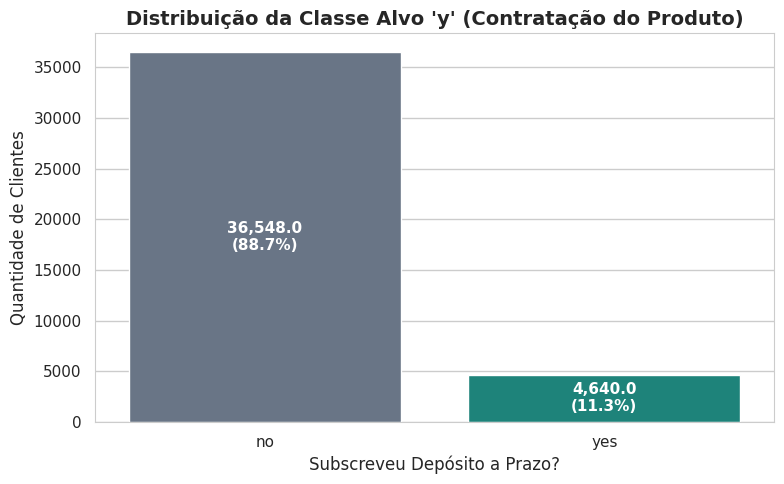

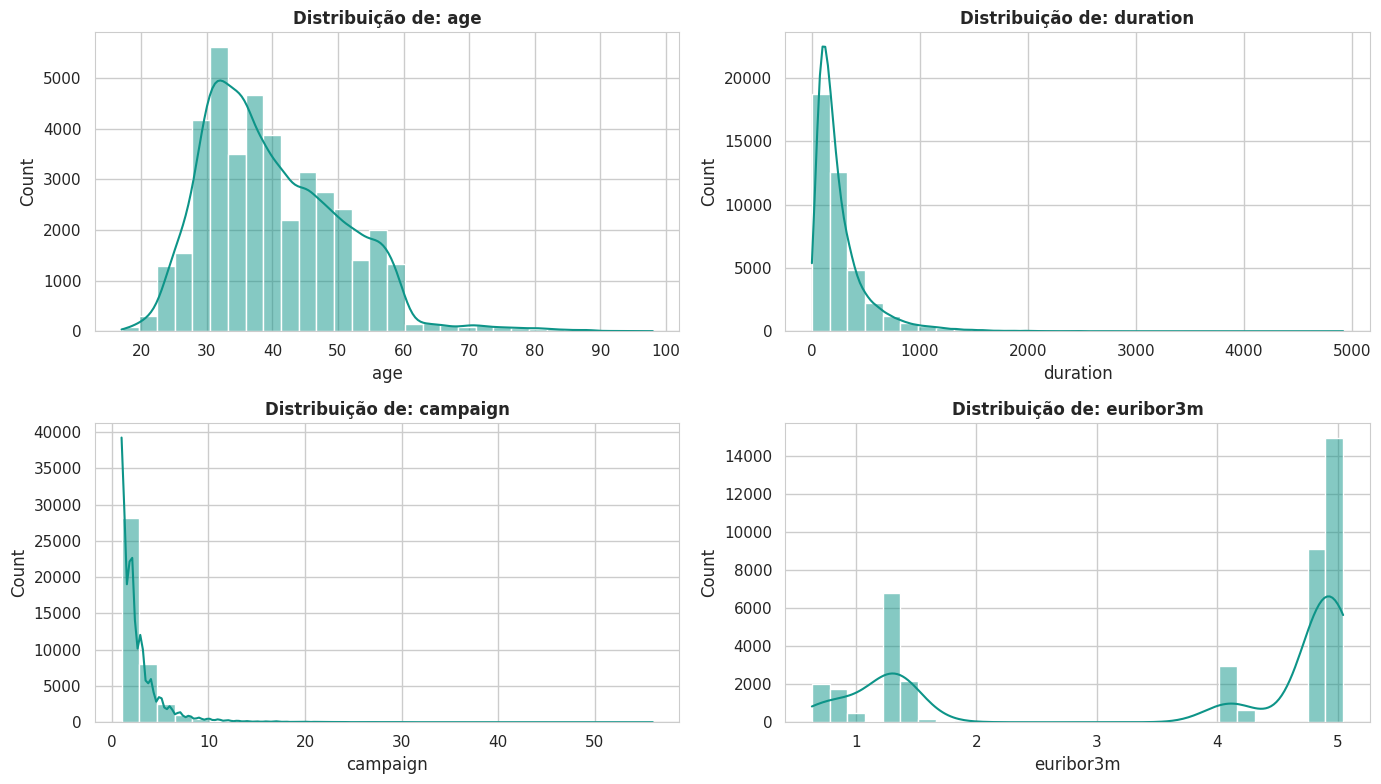


5. ANÁLISE BIVARIADA (FATORES DE CONVERSÃO)


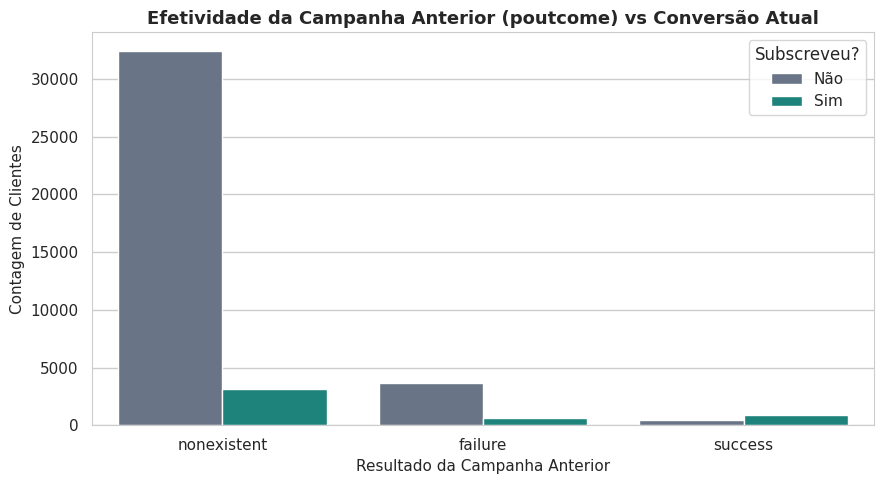

/tmp/ipykernel_1891/4009936395.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_job_conv, x="job", y="y", palette="viridis")


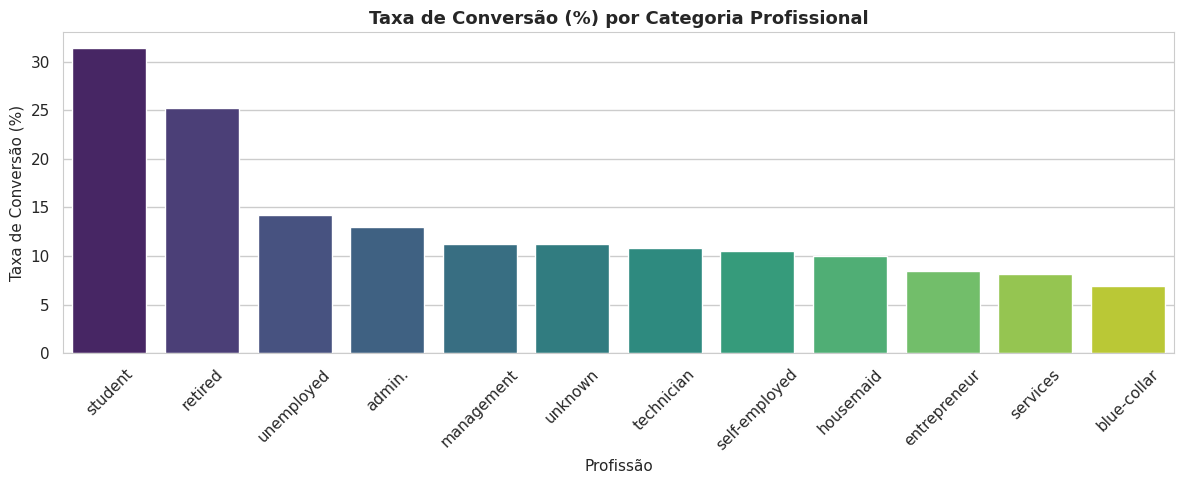


6. RESUMO DOS PRINCIPAIS INSIGHTS OBTIDOS

1. DESBALANCEAMENTO: A classe alvo possui apenas 11.3% de conversão positiva ('yes').
   A acurácia não deve ser utilizada isoladamente; a otimização focará no F1-score.

2. TARGET LEAKAGE EM 'DURATION': A duração do contato apresenta forte relação com o sucesso,
   porém não estará disponível antes de realizar a chamada no ambiente real. Ela deve ser isolada.

3. SINAL HISTÓRICO RELEVANTE: Clientes que converteram na campanha anterior ('poutcome' = 'success')
   apresentam a maior taxa de conversão na campanha atual (> 65%).

4. FATORES MACROECONÔMICOS: A queda na taxa Euribor 3M eleva o apetite dos clientes
   por depósitos a prazo, indicando sensitividade a cenários econômicos.



In [13]:
# ==============================================================================
# TDE 01 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# Projeto: Avaliação de Compra de Produto Bancário (Bank Marketing)
# Métrica de Avaliação: F1-Score (Fase Preditiva Futura)
# ==============================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

# ------------------------------------------------------------------------------
# 1. CARREGAMENTO DOS DADOS VIA GOOGLE DRIVE
# ------------------------------------------------------------------------------

# Conectar/Montar o Google Drive
from google.colab import drive

drive.mount("/content/drive")

caminho_arquivo = "/content/drive/MyDrive/bank-additional-full.csv"

try:
    df_raw = pd.read_csv(caminho_arquivo, sep=";")
    print("\n Dados carregados com sucesso a partir do Google Drive!")
except FileNotFoundError:
    print("\n Arquivo não encontrado no caminho especificado!")
    print(
        "DICA: No menu lateral esquerdo do Colab, clique em 'Arquivos' (ícone de pasta),"
    )
    print(
        "navegue em drive -> MyDrive até encontrar o arquivo, clique com botão direito nele e escolha 'Copiar caminho'."
    )
    print("Em seguida, cole o caminho copiado na variável `caminho_arquivo`.")

df = df_raw.copy()

# ------------------------------------------------------------------------------
# 2. CONHECIMENTO INICIAL DOS DADOS BRUTOS (Rubrica Item 1.2)
# ------------------------------------------------------------------------------
print("\n" + "=" * 37)
print("2. ESTRUTURA INICIAL DA BASE BRUTA")
print("=" * 37)
print(f"Número de Linhas (Observações): {df.shape[0]}")
print(f"Número de Colunas (Atributos): {df.shape[1]}")

print("\n--- Tipos de Variáveis ---")
print(df.dtypes.value_counts())

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"\nVariáveis Numéricas ({len(num_cols)}): {num_cols}")
print(f"Variáveis Categóricas ({len(cat_cols)}): {cat_cols}")

print("\n--- Primeiras 5 Linhas (Dados Brutos) ---")
display(df.head())

# ------------------------------------------------------------------------------
# 3. QUALIDADE E DIAGNÓSTICO DOS DADOS (Rubrica Item 1.3)
# ------------------------------------------------------------------------------
print("\n" + "=" * 40)
print("3. DIAGNÓSTICO DE QUALIDADE DOS DADOS")
print("=" * 40)

# Verificação de NaNs explícitos
nans = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
print(f"Valores Ausentes Explícitos (NaN): {nans}")
print(f"Linhas Duplicadas: {duplicados}")

# Investigação de dados faltantes ocultos ('unknown')
print("\n--- Frequência do valor 'unknown' por Coluna Categórica ---")
unknown_counts = {}
for col in cat_cols:
    count = (df[col] == "unknown").sum()
    if count > 0:
        pct = (count / len(df)) * 100
        unknown_counts[col] = (count, pct)
        print(f"Col: {col:<12} | 'unknown': {count:>6} ({pct:.2f}%)")

# ------------------------------------------------------------------------------
# 4. ANÁLISE UNIVARIADA E DA CLASSE ALVO (Rubrica Items 1.4 & 1.6)
# ------------------------------------------------------------------------------
print("\n" + "=" * 55)
print("4. ANÁLISE UNIVARIADA & DESBALANCEAMENTO DA CLASSE ALVO")
print("=" * 55)

# Distribuição da Variável Alvo 'y'
y_freq = df["y"].value_counts()
y_pct = df["y"].value_counts(normalize=True) * 100

print("Distribuição da Variável Alvo (y):")
for val in y_freq.index:
    print(f"  Target '{val}': {y_freq[val]} ({y_pct[val]:.2f}%)")

# Gráfico 1: Desbalanceamento de Classe
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="y", palette=["#64748b", "#0d9488"])
plt.title(
    "Distribuição da Classe Alvo 'y' (Contratação do Produto)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Subscreveu Depósito a Prazo?", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:,}\n({height/len(df)*100:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, height / 2),
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        weight="bold",
    )

plt.tight_layout()
plt.show()

# Histogramas das Principais Variáveis Numéricas
plt.figure(figsize=(14, 8))
for i, col in enumerate(["age", "duration", "campaign", "euribor3m"], 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color="#0d9488", bins=30)
    plt.title(f"Distribuição de: {col}", fontweight="bold")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. ANÁLISE BIVARIADA & PADRÕES DE NEGÓCIO (Rubrica Items 1.5 & 1.7)
# ------------------------------------------------------------------------------
print("\n" + "=" * 50)
print("5. ANÁLISE BIVARIADA (FATORES DE CONVERSÃO)")
print("=" * 50)

# Relação entre Resultado Anterior (poutcome) e Sucesso Atual
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="poutcome", hue="y", palette=["#64748b", "#0d9488"])
plt.title(
    "Efetividade da Campanha Anterior (poutcome) vs Conversão Atual",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Resultado da Campanha Anterior", fontsize=11)
plt.ylabel("Contagem de Clientes", fontsize=11)
plt.legend(title="Subscreveu?", labels=["Não", "Sim"])
plt.tight_layout()
plt.show()

# Conversão por Tipo de Profissão (job)
df_job_conv = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index()
)
df_job_conv = df_job_conv.sort_values(by="y", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=df_job_conv, x="job", y="y", palette="viridis")
plt.title(
    "Taxa de Conversão (%) por Categoria Profissional",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Profissão", fontsize=11)
plt.ylabel("Taxa de Conversão (%)", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. SÍNTESE DE INSIGHTS & PLANO DE LAPIDAÇÃO (Rubrica Items 1.8 & 1.9)
# ------------------------------------------------------------------------------
print("\n" + "=" * 43)
print("6. RESUMO DOS PRINCIPAIS INSIGHTS OBTIDOS")
print("=" * 43)
print("""
1. DESBALANCEAMENTO: A classe alvo possui apenas 11.3% de conversão positiva ('yes').
   A acurácia não deve ser utilizada isoladamente; a otimização focará no F1-score.

2. TARGET LEAKAGE EM 'DURATION': A duração do contato apresenta forte relação com o sucesso,
   porém não estará disponível antes de realizar a chamada no ambiente real. Ela deve ser isolada.

3. SINAL HISTÓRICO RELEVANTE: Clientes que converteram na campanha anterior ('poutcome' = 'success')
   apresentam a maior taxa de conversão na campanha atual (> 65%).

4. FATORES MACROECONÔMICOS: A queda na taxa Euribor 3M eleva o apetite dos clientes
   por depósitos a prazo, indicando sensitividade a cenários econômicos.
""")